<a href="https://colab.research.google.com/github/ruudtje21/ai-sql-assistant/blob/main/Hasil_Akhir_Yolov8_Rudi_Fresh_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## INSTALL ULTRALYTICS

Menginstall library Ultralytics yang berisi implementasi YOLOv8. Library ini diperlukan untuk training dan inferensi model deteksi objek.

In [ ]:
!pip install ultralytics

## IMPORT LIBRARY


In [ ]:
# Sistem & file management
import os
import shutil
import random
import json

# Komputasi & data
import numpy as np
import pandas as pd
from scipy import stats

# Computer vision
import cv2
from PIL import Image

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Machine learning
from ultralytics import YOLO
import yaml

print("Library diimport!")

## DEFINISI PATH

In [ ]:
base        = '/content/datasets/corrosion_detect'
images_path = f'{base}/images'
labels_path = f'{base}/labels'
img_train   = f'{base}/images/train'
img_val     = f'{base}/images/val'
lbl_train   = f'{base}/labels/train'
lbl_val     = f'{base}/labels/val'

print("Path sudah didefinisikan!")
print(f"Base : {base}")

## SETUP KAGGLE
Menyiapkan kredensial Kaggle agar bisa download dataset.

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## DOWNLOAD DATASET
 Mendownload dataset korosi dari Kaggle dan mengekstraknya ke folder datasets/. Dataset berisi 268 gambar korosi beserta label bounding box-nya.

In [ ]:
# Download dataset dari Kaggle
!kaggle datasets download -d wednesday233/corrosion-detect-dataset

# Ekstrak file zip
!unzip -q corrosion-detect-dataset.zip -d datasets/

Dataset URL: https://www.kaggle.com/datasets/wednesday233/corrosion-detect-dataset
License(s): MIT
corrosion-detect-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace datasets/corrosion detect/images/image1.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## INSTALL ULTRALYTICS
Menginstall library Ultralytics yang berisi implementasi YOLOv8. Library ini diperlukan untuk training dan inferensi model deteksi objek.

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00


##  Cek Kecocokan Gambar & Label
Memverifikasi bahwa setiap gambar memiliki file label yang sesuai. Hasil: 268 gambar dan 268 label — semua cocok.

In [ ]:
# Ambil daftar nama file tanpa ekstensi
img_names = set(os.path.splitext(f)[0] for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png')))
lbl_names = set(os.path.splitext(f)[0] for f in os.listdir(labels_path) if f.endswith('.txt'))

print(f"Gambar ditemukan: {len(img_names)}")
print(f"Label ditemukan : {len(lbl_names)}")

# Cek apakah ada yang tidak cocok
mismatch = img_names - lbl_names
if mismatch:
    print(f"⚠️ Ada {len(mismatch)} gambar yang tidak punya label!")
    print(f"Contoh file yang tidak cocok: {list(mismatch)[:3]}")
else:
    print("✅ Semua gambar sudah memiliki label yang sesuai.")

Gambar ditemukan: 268
Label ditemukan : 268
✅ Semua gambar sudah memiliki label yang sesuai.


## CEK STRUKTUR FOLDER
Menampilkan struktur folder dataset untuk memastikan file tersimpan dengan benar sebelum proses split.

In [ ]:
for root, dirs, files in os.walk('/content/datasets/corrosion_detect'):
    level = root.replace('/content/datasets/corrosion_detect', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for file in files[:3]:  # tampilkan max 3 file per folder
            print(f'{indent}  {file}')

corrosion_detect/
  labels.cache
  labels/
    image39_1.txt
    image53.txt
    image22_1.txt
  images/
    image84.jpeg
    image27_1.jpeg
    image23.jpeg
  .ipynb_checkpoints/


## SPLIT DATASET
Membagi dataset menjadi data training dan data validasi dengan rasio 80:20.

In [ ]:
# Buat folder train/val
for split in ['train', 'val']:
    os.makedirs(os.path.join(images_path, split), exist_ok=True)
    os.makedirs(os.path.join(labels_path, split), exist_ok=True)

# Ambil semua file gambar
all_images = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
random.shuffle(all_images)

# Split 80% train, 20% val
split_idx = int(len(all_images) * 0.8)
train_imgs = all_images[:split_idx]
val_imgs   = all_images[split_idx:]

print(f"Total: {len(all_images)} | Train: {len(train_imgs)} | Val: {len(val_imgs)}")

# Pindahkan file
def move_files(file_list, split):
    for img_file in file_list:
        name = os.path.splitext(img_file)[0]
        txt_file = name + '.txt'

        src_img = os.path.join(images_path, img_file)
        src_lbl = os.path.join(labels_path, txt_file)

        dst_img = os.path.join(images_path, split, img_file)
        dst_lbl = os.path.join(labels_path, split, txt_file)

        shutil.move(src_img, dst_img)
        if os.path.exists(src_lbl):
            shutil.move(src_lbl, dst_lbl)
        else:
            print(f"⚠️ Label tidak ditemukan untuk: {img_file}")

move_files(train_imgs, 'train')
move_files(val_imgs, 'val')

print("✅ Dataset berhasil di-split!")

Total: 268 | Train: 214 | Val: 54
✅ Dataset berhasil di-split!


## SEL VERIFIKASI DATASET
Memverifikasi hasil split dataset — memastikan jumlah gambar dan label di folder train/ dan val/ sudah benar dan sesuai.

In [ ]:
for split in ['train', 'val']:
    imgs = os.listdir(f'{images_path}/{split}')
    lbls = os.listdir(f'{labels_path}/{split}')
    print(f"\n📁 {split}")
    print(f"  Images : {len(imgs)} file")
    print(f"  Labels : {len(lbls)} file")
    print(f"  Contoh image : {imgs[:3]}")
    print(f"  Contoh label : {lbls[:3]}")


📁 train
  Images : 214 file
  Labels : 214 file
  Contoh image : ['image27_1.jpeg', 'image23.jpeg', 'image49.jpeg']
  Contoh label : ['image39_1.txt', 'image53.txt', 'image22_1.txt']

📁 val
  Images : 54 file
  Labels : 54 file
  Contoh image : ['image84.jpeg', 'image106_1.jpeg', 'image78.jpeg']
  Contoh label : ['image20_1.txt', 'image95.txt', 'image115_1.txt']


## CEK ISI LABEL DAN KECOCOKAN FILE
 Memverifikasi isi file label dan memastikan setiap gambar memiliki label yang sesuai (nama file cocok).

In [ ]:
# Cek isi salah satu label
label_file = os.listdir(lbl_train)[0]
with open(f'{lbl_train}/{label_file}') as f:
    content = f.read()
print(f"Isi '{label_file}':\n'{content}'")

# Cek kecocokan nama file image vs label
imgs = set(os.path.splitext(f)[0] for f in os.listdir(img_train))
lbls = set(os.path.splitext(f)[0] for f in os.listdir(lbl_train))

matched   = imgs & lbls
unmatched_imgs = imgs - lbls
unmatched_lbls = lbls - imgs

print(f"\n✅ Cocok     : {len(matched)} file")
print(f"⚠️ Image tanpa label : {len(unmatched_imgs)} → {list(unmatched_imgs)[:5]}")
print(f"⚠️ Label tanpa image : {len(unmatched_lbls)} → {list(unmatched_lbls)[:5]}")

Isi 'image39_1.txt':
'1 0.503245 0.0874126 0.157618 0.174825
1 0.521479 0.275264 0.161121 0.221445
1 0.531524 0.680104 0.152364 0.652681
1 0.840321 0.594474 0.33275 0.160839
1 0.2133 0.219046 0.37303 0.454545
1 0.208149 0.4819 0.406305 0.363636
1 0.873133 0.088441 0.248687 0.20979
1 0.763933 0.300219 0.110333 0.156177
1 0.676419 0.400178 0.1331 0.048951
1 0.924178 0.355821 0.150613 0.25641
'

✅ Cocok     : 214 file
⚠️ Image tanpa label : 0 → []
⚠️ Label tanpa image : 0 → []


## Fix Class Index
Memperbaiki class index di semua file label dari 1 menjadi 0 agar sesuai dengan standar YOLO.

In [ ]:
fixed = 0
for split in ['train', 'val']:
    folder = os.path.join(labels_path, split)
    for txt_file in os.listdir(folder):
        filepath = os.path.join(folder, txt_file)
        with open(filepath, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts:
                parts[0] = '0'  # ganti class index dari 1 → 0
                new_lines.append(' '.join(parts) + '\n')

        with open(filepath, 'w') as f:
            f.writelines(new_lines)
        fixed += 1

print(f"✅ Selesai! {fixed} file label sudah diperbaiki (class 1 → 0)")

✅ Selesai! 268 file label sudah diperbaiki (class 1 → 0)


## CEK KECERAHAN GAMBAR
Mengukur kecerahan rata-rata salah satu gambar. Hasilnya mean brightness 46.18 — sangat gelap (skala 0-255). Ini menjadi justifikasi utama penelitian tentang low-light conditions.

In [ ]:
img_path = '/content/datasets/corrosion_detect/images/train/image27_1.jpeg'
img = np.array(Image.open(img_path))

print(f"Mean brightness : {img.mean():.2f}")
print(f"Min pixel       : {img.min()}")
print(f"Max pixel       : {img.max()}")
print(f"Std             : {img.std():.2f}")

Mean brightness : 46.18
Min pixel       : 0
Max pixel       : 255
Std             : 55.27


## ANALISIS KELAYAKAN CITRA
 Implementasi langsung untuk menilai kelayakan citra sebelum didegradasi:

Y: Konversi ke luminance berdasarkan persepsi manusia
mean_Y ≤ 10: Citra terlalu gelap, skip
std_Y < 5: Variasi intensitas terlalu kecil, skip
SNR rough: Rasio sinyal-noise sederhana
SNR proper: Rasio sinyal-noise menggunakan Gaussian Blur
Hasil: Semua 268 citra layak didegradasi.

In [ ]:
results = []

for split in ['train', 'val']:
    folder = os.path.join(images_path, split)
    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        fpath = os.path.join(folder, fname)
        img_bgr = cv2.imread(fpath)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)

        # Luminance Y = 0.299R + 0.587G + 0.114B
        Y = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]

        mean_Y = Y.mean()
        std_Y  = Y.std()

        # SNR rough
        snr_rough = mean_Y / std_Y if std_Y > 0 else 0

        # SNR proper
        signal = cv2.GaussianBlur(Y.astype(np.float32), (5,5), 0).astype(float)
        noise  = Y - signal
        var_signal = np.var(signal)
        var_noise  = np.var(noise)
        snr = var_signal / var_noise if var_noise > 0 else 0

        # Flag: layak didegradasi?
        layak = True
        alasan = []
        if mean_Y <= 10:
            layak = False
            alasan.append("mean_Y ≤ 10")
        if std_Y < 5:
            layak = False
            alasan.append("std_Y terlalu kecil")

        results.append({
            'file': fname,
            'split': split,
            'mean_Y': round(mean_Y, 2),
            'std_Y': round(std_Y, 2),
            'snr_rough': round(snr_rough, 3),
            'snr': round(snr, 3),
            'layak_degradasi': layak,
            'alasan': ', '.join(alasan) if alasan else '-'
        })

df = pd.DataFrame(results)
print(df.groupby(['split', 'layak_degradasi']).size())
print(f"\nTotal layak didegradasi : {df['layak_degradasi'].sum()}")
print(f"Total tidak layak       : {(~df['layak_degradasi']).sum()}")
df.to_csv('citra_quality_check.csv', index=False)
print("\n✅ Hasil disimpan ke citra_quality_check.csv")

split  layak_degradasi
train  True               214
val    True                54
dtype: int64

Total layak didegradasi : 268
Total tidak layak       : 0

✅ Hasil disimpan ke citra_quality_check.csv


## HISTOGRAM LUMINANCE
Membuat histogram distribusi luminance untuk 6 sampel gambar. Ini untuk melihat apakah citra sudah "mentok gelap" (semua pixel menumpuk di nilai rendah). Hasilnya menunjukkan mayoritas citra memang gelap dengan mean Y antara 46-120.

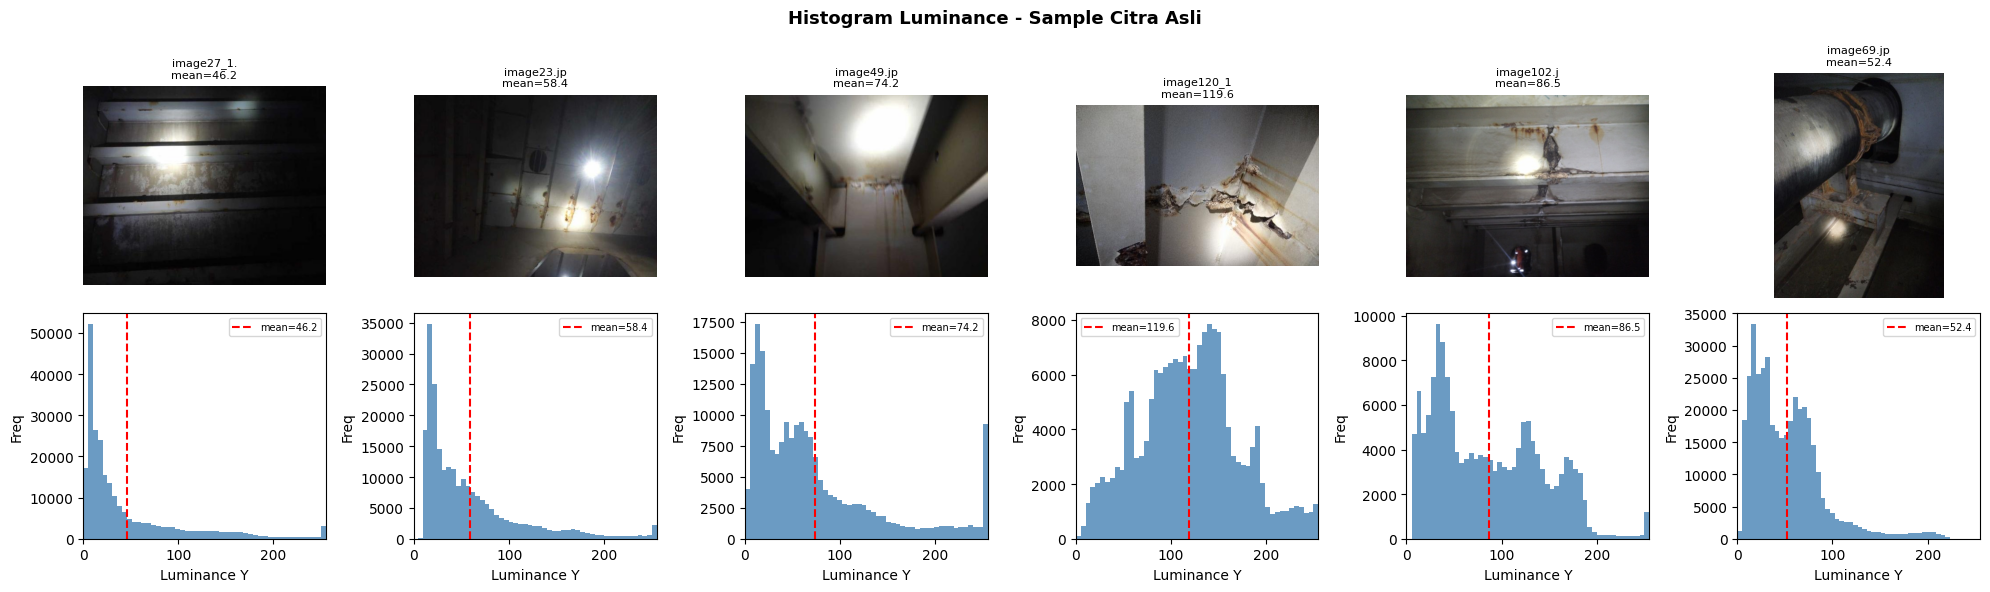

✅ Histogram disimpan ke histogram_luminance.png


In [ ]:
files = os.listdir(img_train)[:6]  # ambil 6 sampel

fig, axes = plt.subplots(2, 6, figsize=(20, 6))

for i, fname in enumerate(files):
    fpath = os.path.join(img_train, fname)
    img_rgb = cv2.cvtColor(cv2.imread(fpath), cv2.COLOR_BGR2RGB).astype(float)
    Y = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]

    # Tampilkan gambar
    axes[0, i].imshow(img_rgb.astype(np.uint8))
    axes[0, i].set_title(f'{fname[:10]}\nmean={Y.mean():.1f}', fontsize=8)
    axes[0, i].axis('off')

    # Histogram luminance
    axes[1, i].hist(Y.flatten(), bins=50, color='steelblue', alpha=0.8)
    axes[1, i].axvline(Y.mean(), color='red', linestyle='--', label=f'mean={Y.mean():.1f}')
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_xlabel('Luminance Y')
    axes[1, i].set_ylabel('Freq')
    axes[1, i].legend(fontsize=7)

plt.suptitle('Histogram Luminance - Sample Citra Asli', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogram_luminance.png', dpi=150)
plt.show()
print("Histogram disimpan ke histogram_luminance.png")

## DEGRADASI TEST SET TERKONTROL
Membuat test set terdegradasi dengan 2 level sesuai metodologi dosen. brightness_factor menggelapkan gambar, contrast_factor mengurangi kontras. Ada aturan berhenti agar degradasi tidak menghasilkan gambar yang tidak bermakna. Hasilnya: deg_mild 54 OK, deg_moderate 47 OK + 7 SKIP (terlalu gelap).

In [ ]:
log          = []

levels = [
    (0.85, 0.90, 'deg_mild'),
    (0.75, 0.80, 'deg_moderate'),
]

for _, _, ln in levels:
    os.makedirs(f'{images_path}/{ln}', exist_ok=True)

for fname in os.listdir(test_ori_dir):
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue

    fpath   = os.path.join(test_ori_dir, fname)
    img_bgr = cv2.imread(fpath)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)

    Y_ori     = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    mean_awal = float(Y_ori.mean())
    std_awal  = float(Y_ori.std())

    for bf, cf, ln in levels:
        deg      = img_rgb.copy() * bf
        mean_d   = deg.mean(axis=(0,1), keepdims=True)
        deg      = (deg - mean_d) * cf + mean_d
        deg      = np.clip(deg, 0, 255)

        Y_deg    = 0.299*deg[:,:,0] + 0.587*deg[:,:,1] + 0.114*deg[:,:,2]
        mean_deg = float(Y_deg.mean())
        std_deg  = float(Y_deg.std())

        alasan = []
        if mean_deg < 0.7 * mean_awal:
            alasan.append(f"mean {mean_deg:.1f} < {0.7*mean_awal:.1f}")
        if std_deg < 0.6 * std_awal:
            alasan.append(f"std {std_deg:.1f} < {0.6*std_awal:.1f}")

        out_path = f'{images_path}/{ln}/{fname}'
        if alasan:
            shutil.copy(fpath, out_path)
            status = 'SKIP'
        else:
            cv2.imwrite(out_path, cv2.cvtColor(deg.astype(np.uint8), cv2.COLOR_RGB2BGR))
            status = 'OK'

        log.append({'file': fname, 'level': ln, 'status': status,
                    'mean_ori': round(mean_awal,2), 'std_ori': round(std_awal,2),
                    'mean_deg': round(mean_deg,2),  'std_deg': round(std_deg,2),
                    'alasan': ', '.join(alasan) if alasan else '-'})

df_log = pd.DataFrame(log)
print(df_log.groupby(['level','status']).size())
df_log.to_csv('degradasi_log_fixed.csv', index=False)
print("✅ Selesai!")

level         status
deg_mild      OK        54
deg_moderate  OK        47
              SKIP       7
dtype: int64
✅ Selesai!


## CEK DETAIL SKIP
Menampilkan detail 7 citra yang tidak didegradasi di level moderate karena contrast sudah terlalu rendah setelah degradasi (std_deg < 0.6 × std_awal). Citra-citra ini tetap disertakan menggunakan gambar aslinya.

In [ ]:
skip = df_log[df_log['status']=='SKIP']
print(skip[['file','level','mean_ori','std_ori','mean_deg','std_deg','alasan']].to_string(index=False))

           file        level  mean_ori  std_ori  mean_deg  std_deg          alasan
  image122.jpeg deg_moderate    102.80    52.81     77.10    31.68 std 31.7 < 31.7
image102_1.jpeg deg_moderate     76.07    54.91     57.05    32.95 std 32.9 < 32.9
  image109.jpeg deg_moderate     72.91    31.19     54.68    18.71 std 18.7 < 18.7
    image3.jpeg deg_moderate     52.64    41.72     39.48    25.03 std 25.0 < 25.0
 image31_1.jpeg deg_moderate     48.02    52.08     36.01    31.25 std 31.2 < 31.2
   image22.jpeg deg_moderate     48.90    54.90     36.67    32.94 std 32.9 < 32.9
   image51.jpeg deg_moderate     46.66    60.77     35.00    36.46 std 36.5 < 36.5


##AUGMENTASI(CLAHE dan GAMMA)
Membuat dataset augmentasi untuk training Model B dan C:

CLAHE (Contrast Limited Adaptive Histogram Equalization): Meningkatkan kontras lokal secara adaptif, cocok untuk gambar gelap
Gamma Correction (γ=1.5): Mencerahkan gambar secara global menggunakan kurva gamma
Masing-masing menghasilkan 214 gambar augmentasi.

In [ ]:
# Buat folder augmented
for aug in ['clahe', 'gamma']:
    os.makedirs(f'{images_path}/train_{aug}', exist_ok=True)
    os.makedirs(f'{labels_path}/train_{aug}', exist_ok=True)

def apply_clahe(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l,a,b]), cv2.COLOR_LAB2BGR)

def apply_gamma(img_bgr, gamma=1.5):
    inv_gamma = 1.0 / gamma
    table = np.array([((i/255.0)**inv_gamma)*255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img_bgr, table)

for fname in os.listdir(img_train):
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue

    name     = os.path.splitext(fname)[0]
    src_img  = os.path.join(img_train, fname)
    src_lbl  = os.path.join(lbl_train, name + '.txt')
    img_bgr  = cv2.imread(src_img)

    # CLAHE
    cv2.imwrite(f'{images_path}/train_clahe/{fname}', apply_clahe(img_bgr))
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, f'{labels_path}/train_clahe/{name}.txt')

    # Gamma
    cv2.imwrite(f'{images_path}/train_gamma/{fname}', apply_gamma(img_bgr))
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, f'{labels_path}/train_gamma/{name}.txt')

print(f"✅ CLAHE : {len(os.listdir(f'{images_path}/train_clahe'))} gambar")
print(f"✅ Gamma : {len(os.listdir(f'{images_path}/train_gamma'))} gambar")

✅ CLAHE : 214 gambar
✅ Gamma : 214 gambar


## BUAT YAML KONFIGURASI
Membuat file konfigurasi YAML untuk 3 model YOLO. YAML ini memberitahu YOLO lokasi dataset, jumlah class, dan nama class. Model B dan C menggunakan 2x lebih banyak data training (428 gambar) karena ada augmentasi.

In [ ]:
# Model A — dataset asli saja
yaml_a = {
    'path': base,
    'train': 'images/train',
    'val':   'images/val',
    'nc': 1,
    'names': ['corrosion']
}

# Model B — asli + CLAHE
yaml_b = {
    'path': base,
    'train': ['images/train', 'images/train_clahe'],
    'val':   'images/val',
    'nc': 1,
    'names': ['corrosion']
}

# Model C — asli + Gamma
yaml_c = {
    'path': base,
    'train': ['images/train', 'images/train_gamma'],
    'val':   'images/val',
    'nc': 1,
    'names': ['corrosion']
}

for name, cfg in [('model_A', yaml_a), ('model_B', yaml_b), ('model_C', yaml_c)]:
    with open(f'{name}.yaml', 'w') as f:
        yaml.dump(cfg, f)
    print(f"✅ {name}.yaml dibuat")

✅ model_A.yaml dibuat
✅ model_B.yaml dibuat
✅ model_C.yaml dibuat


## TRAINING 3 MODEL YOLO
Melatih 3 model YOLOv8n dengan pretrained weights:

yolo_A: Baseline — hanya dataset asli
yolo_B: Dataset asli + CLAHE augmentation
yolo_C: Dataset asli + Gamma augmentation
patience=10: Training berhenti otomatis jika tidak ada peningkatan selama 10 epoch
Hasil: yolo_A mAP50=0.425, yolo_B=0.398, yolo_C=0.437

In [ ]:
for model_name, yaml_file in [
    ('yolo_A', 'model_A.yaml'),
    ('yolo_B', 'model_B.yaml'),
    ('yolo_C', 'model_C.yaml'),
]:
    print(f"\n{'='*40}")
    print(f"Training {model_name}...")
    print(f"{'='*40}")

    model = YOLO('yolov8n.pt')
    model.train(
        data=yaml_file,
        epochs=50,
        imgsz=640,
        batch=16,
        name=model_name,
        project='/content/runs',
        patience=10,
        device=0
    )
    print(f"✅ {model_name} selesai!")

print("Semua model selesai ditraining!")


Training yolo_A...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=model_A.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_A, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10,

## CEK HASIL TRAINING
Membaca file results.csv dari setiap model untuk menampilkan performa terbaik. mAP50 (mean Average Precision at IoU=0.50) adalah metrik standar evaluasi model deteksi objek.

In [ ]:
for model_name in ['yolo_A', 'yolo_B', 'yolo_C']:
    csv_path = f'/content/runs/{model_name}/results.csv'
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    best_map50 = df['metrics/mAP50(B)'].max()
    best_epoch = df['metrics/mAP50(B)'].idxmax() + 1
    print(f"📊 {model_name} → Best mAP50: {best_map50:.3f} (epoch {best_epoch})")

📊 yolo_A → Best mAP50: 0.425 (epoch 37)
📊 yolo_B → Best mAP50: 0.398 (epoch 13)
📊 yolo_C → Best mAP50: 0.437 (epoch 36)


##EVALUASI PADA TEST SET TERDEGRADASI
Menjalankan prediksi 3 model pada 3 test set (original, deg_mild, deg_moderate) dan menghitung 3 indikator kerusakan:

n_instance: Jumlah deteksi korosi per gambar
area_ratio: Total luas bounding box relatif terhadap ukuran gambar
box_density: Kepadatan deteksi per juta pixel.

In [ ]:
models = {
    'yolo_A': '/content/runs/yolo_A/weights/best.pt',
    'yolo_B': '/content/runs/yolo_B/weights/best.pt',
    'yolo_C': '/content/runs/yolo_C/weights/best.pt',
}

test_sets = {
    'original':     img_val,
    'deg_mild':     f'{images_path}/deg_mild',
    'deg_moderate': f'{images_path}/deg_moderate',
}

results_log = []

for model_name, weight_path in models.items():
    model = YOLO(weight_path)
    for test_name, test_path in test_sets.items():
        print(f"🔍 Evaluasi {model_name} pada {test_name}...")

        preds = model.predict(
            source=test_path,
            conf=0.25,
            save=False,
            verbose=False
        )

        for pred in preds:
            fname      = os.path.basename(pred.path)
            boxes      = pred.boxes
            n_instance = len(boxes)
            img_h, img_w = pred.orig_shape

            if n_instance > 0:
                areas = []
                for box in boxes.xywhn:
                    w, h = box[2].item(), box[3].item()
                    areas.append(w * h)
                area_ratio  = sum(areas)
                box_density = n_instance / (img_w * img_h) * 1e6
            else:
                area_ratio  = 0.0
                box_density = 0.0

            results_log.append({
                'model':      model_name,
                'test_set':   test_name,
                'file':       fname,
                'n_instance': n_instance,
                'area_ratio': round(area_ratio, 4),
                'box_density': round(box_density, 4),
            })

df_results = pd.DataFrame(results_log)
df_results.to_csv('eval_results.csv', index=False)
print("\n✅ Evaluasi selesai! Disimpan ke eval_results.csv")
print(df_results.groupby(['model','test_set'])['n_instance'].mean().round(2))

🔍 Evaluasi yolo_A pada original...
🔍 Evaluasi yolo_A pada deg_mild...
🔍 Evaluasi yolo_A pada deg_moderate...
🔍 Evaluasi yolo_B pada original...
🔍 Evaluasi yolo_B pada deg_mild...
🔍 Evaluasi yolo_B pada deg_moderate...
🔍 Evaluasi yolo_C pada original...
🔍 Evaluasi yolo_C pada deg_mild...
🔍 Evaluasi yolo_C pada deg_moderate...

✅ Evaluasi selesai! Disimpan ke eval_results.csv
model   test_set    
yolo_A  deg_mild        4.80
        deg_moderate    4.37
        original        4.81
yolo_B  deg_mild        7.44
        deg_moderate    7.37
        original        7.56
yolo_C  deg_mild        5.91
        deg_moderate    5.46
        original        5.98
Name: n_instance, dtype: float64


## HITUNG STABILITAS (CV,RELATIVE CHANGE,SPEARMAN)
Menghitung 3 metrik stabilitas sesuai permintaan dosen:

CV (Coefficient of Variation): Mengukur variabilitas nilai — makin kecil makin stabil
Relative Change: Perubahan % dari original ke deg_moderate — makin kecil makin stabil
Spearman: Arah tren penurunan (-1.0 = turun monoton, konsisten).

In [ ]:
df = pd.read_csv('eval_results.csv')

metrics_cols = ['n_instance', 'area_ratio', 'box_density']
test_order   = ['original', 'deg_mild', 'deg_moderate']
stability_log = []

for model_name in df['model'].unique():
    df_model = df[df['model'] == model_name]

    for metric in metrics_cols:
        # Rata-rata per test set
        means = {}
        for ts in test_order:
            means[ts] = df_model[df_model['test_set']==ts][metric].mean()

        vals = [means[ts] for ts in test_order]

        # 1. Coefficient of Variation (CV)
        cv = (np.std(vals) / np.mean(vals) * 100) if np.mean(vals) != 0 else 0

        # 2. Relative Change (%) original → deg_moderate
        rel_change = ((means['deg_moderate'] - means['original']) / means['original'] * 100) \
                     if means['original'] != 0 else 0

        # 3. Spearman Rank Correlation (nilai vs degradasi level)
        deg_levels = [0, 1, 2]  # original=0, mild=1, moderate=2
        spearman_r, spearman_p = stats.spearmanr(deg_levels, vals)

        stability_log.append({
            'model':       model_name,
            'metric':      metric,
            'mean_ori':    round(means['original'], 4),
            'mean_mild':   round(means['deg_mild'], 4),
            'mean_mod':    round(means['deg_moderate'], 4),
            'CV(%)':       round(cv, 2),
            'rel_change(%)': round(rel_change, 2),
            'spearman_r':  round(spearman_r, 3),
            'spearman_p':  round(spearman_p, 3),
        })

df_stability = pd.DataFrame(stability_log)
df_stability.to_csv('stability_results.csv', index=False)

# Tampilkan per metrik
for metric in metrics_cols:
    print(f"\n{'='*55}")
    print(f"📊 Metrik: {metric}")
    print(f"{'='*55}")
    sub = df_stability[df_stability['metric']==metric]
    print(sub[['model','CV(%)','rel_change(%)','spearman_r']].to_string(index=False))

print("\n✅ Disimpan ke stability_results.csv")


📊 Metrik: n_instance
 model  CV(%)  rel_change(%)  spearman_r
yolo_A   4.40          -9.23        -1.0
yolo_B   1.02          -2.45        -1.0
yolo_C   3.96          -8.67        -1.0

📊 Metrik: area_ratio
 model  CV(%)  rel_change(%)  spearman_r
yolo_A   8.25         -18.24        -1.0
yolo_B   1.43          -3.14        -1.0
yolo_C   6.08         -11.69        -0.5

📊 Metrik: box_density
 model  CV(%)  rel_change(%)  spearman_r
yolo_A   3.97          -7.18        -0.5
yolo_B   2.20          -5.23        -1.0
yolo_C   3.60          -7.66        -1.0

✅ Disimpan ke stability_results.csv


## RANKING STABILITY
Mengukur apakah urutan tingkat kerusakan antar gambar tetap konsisten saat citra didegradasi. Jika gambar A lebih rusak dari gambar B di kondisi normal, apakah tetap demikian saat gelap? Spearman > 0.7 = ranking stabil. Hasil: semua model > 0.88.

In [ ]:
df = pd.read_csv('eval_results.csv')
metrics_cols  = ['n_instance', 'area_ratio', 'box_density']
test_order    = ['original', 'deg_mild', 'deg_moderate']
ranking_log   = []

for model_name in df['model'].unique():
    df_model = df[df['model'] == model_name]

    for metric in metrics_cols:
        # Ambil nilai per file di tiap test set
        ranks = {}
        for ts in test_order:
            vals = df_model[df_model['test_set']==ts].set_index('file')[metric]
            ranks[ts] = vals.rank(ascending=False)

        # Gabungkan file yang ada di semua test set
        common_files = set(ranks['original'].index)
        for ts in test_order[1:]:
            common_files &= set(ranks[ts].index)
        common_files = list(common_files)

        # Spearman original vs deg_mild
        r1, _ = stats.spearmanr(
            ranks['original'][common_files],
            ranks['deg_mild'][common_files]
        )
        # Spearman original vs deg_moderate
        r2, _ = stats.spearmanr(
            ranks['original'][common_files],
            ranks['deg_moderate'][common_files]
        )

        ranking_log.append({
            'model':               model_name,
            'metric':              metric,
            'spearman_ori_mild':   round(r1, 3),
            'spearman_ori_mod':    round(r2, 3),
            'rank_stable':         'YA' if r2 > 0.7 else 'TIDAK'
        })

df_ranking = pd.DataFrame(ranking_log)
df_ranking.to_csv('ranking_stability.csv', index=False)

for metric in metrics_cols:
    print(f"\n{'='*55}")
    print(f"📊 Ranking Stability: {metric}")
    print(f"{'='*55}")
    sub = df_ranking[df_ranking['metric']==metric]
    print(sub[['model','spearman_ori_mild','spearman_ori_mod','rank_stable']].to_string(index=False))

print("\n✅ Disimpan ke ranking_stability.csv")


📊 Ranking Stability: n_instance
 model  spearman_ori_mild  spearman_ori_mod rank_stable
yolo_A              0.943             0.890          YA
yolo_B              0.908             0.885          YA
yolo_C              0.940             0.897          YA

📊 Ranking Stability: area_ratio
 model  spearman_ori_mild  spearman_ori_mod rank_stable
yolo_A              0.938             0.895          YA
yolo_B              0.949             0.937          YA
yolo_C              0.980             0.956          YA

📊 Ranking Stability: box_density
 model  spearman_ori_mild  spearman_ori_mod rank_stable
yolo_A              0.960             0.908          YA
yolo_B              0.954             0.954          YA
yolo_C              0.962             0.929          YA

✅ Disimpan ke ranking_stability.csv


## VISUALISASI STABILITAS
Membuat grafik perbandingan 3 metrik stabilitas untuk ketiga model dalam satu figure. Disimpan ke stability_visualization.png sebagai output visual utama penelitian.

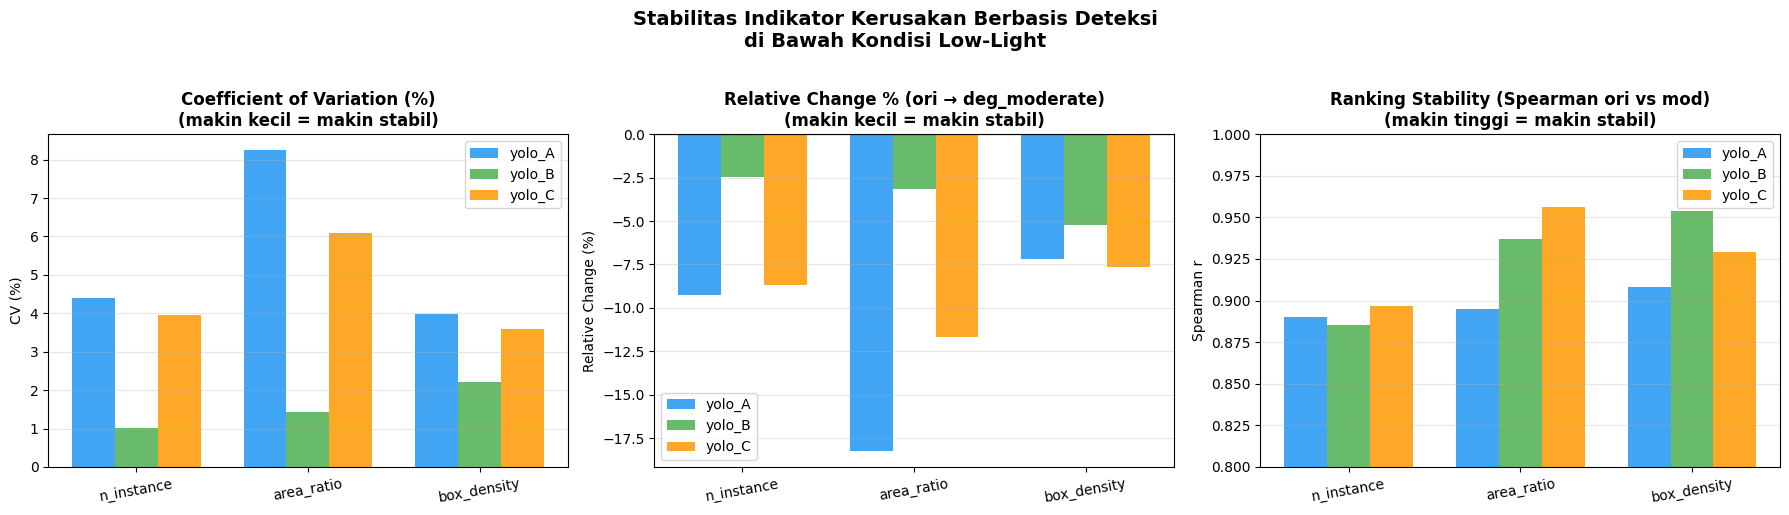

✅ Visualisasi disimpan ke stability_visualization.png


In [ ]:
df_s = pd.read_csv('stability_results.csv')
df_r = pd.read_csv('ranking_stability.csv')

metrics   = ['n_instance', 'area_ratio', 'box_density']
models    = ['yolo_A', 'yolo_B', 'yolo_C']
colors    = ['#2196F3', '#4CAF50', '#FF9800']
x         = np.arange(len(metrics))
width     = 0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CV
ax = axes[0]
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_s[(df_s['model']==model) & (df_s['metric']==m)]['CV(%)'].values[0] for m in metrics]
    ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)
ax.set_title('Coefficient of Variation (%)\n(makin kecil = makin stabil)', fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(metrics, rotation=10)
ax.set_ylabel('CV (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# Plot 2: Relative Change
ax = axes[1]
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_s[(df_s['model']==model) & (df_s['metric']==m)]['rel_change(%)'].values[0] for m in metrics]
    ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)
ax.set_title('Relative Change % (ori → deg_moderate)\n(makin kecil = makin stabil)', fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(metrics, rotation=10)
ax.set_ylabel('Relative Change (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8)

# Plot 3: Ranking Stability
ax = axes[2]
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_r[(df_r['model']==model) & (df_r['metric']==m)]['spearman_ori_mod'].values[0] for m in metrics]
    ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)
ax.set_title('Ranking Stability (Spearman ori vs mod)\n(makin tinggi = makin stabil)', fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(metrics, rotation=10)
ax.set_ylabel('Spearman r'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.8, 1.0)
ax.axhline(0.7, color='red', linestyle='--', label='threshold 0.7')

plt.suptitle('Stabilitas Indikator Kerusakan Berbasis Deteksi\ndi Bawah Kondisi Low-Light',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('stability_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi disimpan ke stability_visualization.png")

##REKAP HASIL YOLO
Menggabungkan semua hasil (stability + ranking) ke dalam satu tabel rekap lengkap per metrik. Disimpan ke rekap_akhir_yolo.csv sebagai dokumentasi final bagian YOLO.

In [ ]:
df_s = pd.read_csv('stability_results.csv')
df_r = pd.read_csv('ranking_stability.csv')

rows = []
for model in ['yolo_A', 'yolo_B', 'yolo_C']:
    for metric in ['n_instance', 'area_ratio', 'box_density']:
        s = df_s[(df_s['model']==model) & (df_s['metric']==metric)].iloc[0]
        r = df_r[(df_r['model']==model) & (df_r['metric']==metric)].iloc[0]
        rows.append({
            'Model': model,
            'Metrik': metric,
            'Mean_Ori': s['mean_ori'],
            'Mean_Mild': s['mean_mild'],
            'Mean_Moderate': s['mean_mod'],
            'CV_pct': s['CV(%)'],
            'RelChange_pct': s['rel_change(%)'],
            'Spearman_trend': s['spearman_r'],
            'Spearman_Ori_Mild': r['spearman_ori_mild'],
            'Spearman_Ori_Mod': r['spearman_ori_mod'],
            'Rank_Stabil': r['rank_stable'],
        })

df_rekap = pd.DataFrame(rows)
df_rekap.to_csv('rekap_akhir_yolo.csv', index=False)
print("rekap dibuat!")
print(df_rekap.shape)

rekap dibuat!
(9, 11)


## TAMPILAN REKAP AKHIR YOLO
Menampilkan tabel rekap lengkap hasil analisis stabilitas YOLO dalam format yang rapi dan mudah dibaca, dikelompokkan per metrik.

In [ ]:
for metric in ['n_instance', 'area_ratio', 'box_density']:
    print("\n" + "="*70)
    print("Metrik: " + metric)
    print("="*70)
    sub = df_rekap[df_rekap['Metrik']==metric]
    print(sub[['Model','Mean_Ori','Mean_Mild','Mean_Moderate',
               'CV_pct','RelChange_pct','Spearman_trend',
               'Spearman_Ori_Mod','Rank_Stabil']].to_string(index=False))

print("\nSelesai! Disimpan ke rekap_akhir_yolo.csv")


Metrik: n_instance
 Model  Mean_Ori  Mean_Mild  Mean_Moderate  CV_pct  RelChange_pct  Spearman_trend  Spearman_Ori_Mod Rank_Stabil
yolo_A    4.8148     4.7963         4.3704    4.40          -9.23            -1.0             0.890          YA
yolo_B    7.5556     7.4444         7.3704    1.02          -2.45            -1.0             0.885          YA
yolo_C    5.9815     5.9074         5.4630    3.96          -8.67            -1.0             0.897          YA

Metrik: area_ratio
 Model  Mean_Ori  Mean_Mild  Mean_Moderate  CV_pct  RelChange_pct  Spearman_trend  Spearman_Ori_Mod Rank_Stabil
yolo_A    0.1227     0.1152         0.1004    8.25         -18.24            -1.0             0.895          YA
yolo_B    0.1735     0.1687         0.1681    1.43          -3.14            -1.0             0.937          YA
yolo_C    0.1856     0.1882         0.1639    6.08         -11.69            -0.5             0.956          YA

Metrik: box_density
 Model  Mean_Ori  Mean_Mild  Mean_Moderate 